datasetLink: https://www.kaggle.com/datasets/saurabhshahane/bengali-sentiment-classification

In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Data

In [103]:
#unzip the data
!unzip /content/dataset.zip

Archive:  /content/dataset.zip
replace README.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

# New Section

In [104]:
with open("/content/all_positive_8500.txt" ,'r', encoding= 'utf-8') as f:
  positive_texts = f.readlines()

In [105]:
for text in positive_texts[:10] :
  print(text)

 অসাধারণ নিশো বস্ আর অমি ভাইকেও।

 আমার দেখা বেস্ট নাটক

 নাটক টা অনেক সুন্দর হয়েছে,,,,আফরান নিশো ভাইয়া আপনিই বেস্ট,,,,,I love you ভাইয়া,,, এবং তানজিল আপুকে

 সত্যি অসাধারণ একটি রিলেশন

 মজা পাইছি ভাষা গুলো কেমন লাগলো

 খুব সুন্দর হয়েছে

 অনেক হাসির একটা নাটক এবং রুমান্টিক

 বিউটিফুল

 ভাললোই লাগল

 কখনো নাটক দেখে চোখে পানি আসেনি ,,,,but এই নাটকটা দেখে বৃষ্টির মতো পানি নামিয়েছে দুচোখ দিয়ে ,,,,,!!!! গল্পটা ভালো ছিল ,,,,,!!!!



In [106]:
with open("/content/all_negative_3307.txt" ,'r', encoding= 'utf-8') as f:
  negative_texts = f.readlines()

In [107]:
for text in negative_texts[:10] :
  print(text)

 আমার জীবনের সবথেকে ফালতু একটা নাটক এইটা

 সাধারণ মানুষ টিভি চ্যানেল গুলো ছুড়ে ফেলে দিয়ে ইউটিউবে নাটক দেখে কারণ  টিভি চ্যানেল গুলোর বিরক্তিকর এ্যাডগুলোর জন্য। এখন এখানেও সেই ভাইরাস / রোগ ঢুকে গেছে। এই কম্পিটিশন এর যুগে ইউটিউব কতৃপক্ষ যদি বিজ্ঞাপন দেয়ার বিষয়ে আরও সচেতন এবং সুদূরপ্রসারী চিন্তা ভাবনা না করেন এক সময় আপনারাও কালের গর্ভে হারিয়ে যাবেন।

 স্টুডেন্ট ওরে একটা থাপ্পড় মারো

 নাটকটিতে কথা থেকে মিউজিকের সাউন্ডটা বেশি হয়ে গেছে,যে কারনে কথাগুলো অনেক সময় ক্লিয়ার শোনা যায় না।

 পাকনা মেয়াটা একটা বাজে

 ধূস পুরো ফালতু. স্টোরি খুব দুর্বল

 কথার চেয়ে মিউজিকের আওয়াজ বেশি

 আমি আফরান নিশোর  অনেক বড় ফ্যান কিন্তু ইদানিং সে অনেক বাজে নাটক করছে তার উচিৎ দেখে শুনে কাজ করা

 নাটকের শেষাংশে সনাতনি কায়দা অবলম্বন করা হয়েছে, যা আমার কাছে ভালো লাগে নাই, চাই নতুনত্ব!

 শেষ টা ভাল লাগলো না



In [ ]:
positive_texts = [text.strip() for text in positive_texts]
negative_texts = [text.strip() for text in negative_texts]


In [108]:
texts = positive_texts + negative_texts

In [109]:
len(positive_texts), len(negative_texts)

(8500, 3307)

In [110]:
negative_labels = [0]*len(negative_texts)
positive_labels = [1]*len(positive_texts)

In [111]:
len(negative_labels), len(positive_labels)

(3307, 8500)

In [ ]:
labels=positive_labels+negative_labels

In [112]:
df =pd.DataFrame({
    'text':texts,
    'label':labels
})
df.head()

,text,label
0,অসাধারণ নিশো বস্ আর অমি ভাইকেও।\n,1
1,আমার দেখা বেস্ট নাটক\n,1
2,"নাটক টা অনেক সুন্দর হয়েছে,,,,আফরান নিশো ভাইয...",1
3,সত্যি অসাধারণ একটি রিলেশন\n,1
4,মজা পাইছি ভাষা গুলো কেমন লাগলো\n,1


In [113]:
df.tail()

,text,label
11802,পালতু নাটক একটা\n,0
11803,"ফালতু, আলতু, টালতু\n",0
11804,শালা আসোলেই পেটুক\n,0
11805,বেহাইয়া জামাই\n,0
11806,নতুন অভিনয়শিল্পী। অভারএ্যাকটিং\n,0


In [114]:
df.sample(frac=1,random_state=42).reset_index(drop=True)


,text,label
0,"আমার বাংলাদেশের নাটকের ভুতে ধরেছে, ওঝা কোথায় ...",1
1,"ভাই, আপনার হার্ড ফ্যান আমি!বাট এইযে এই নাটকে ...",0
2,অনেক ভালো একটা নাটক ।।অনেক ভালোবাসি ভাই তুমাক...,1
3,বালের নাটক বালের কনসেপ্ট\n,0
4,"দারুন হয়েছে, এই রকম নাটক আরো দেখতে চাই\n",1
...,...,...
11802,বালের গল্প লিখছে হালায়।এইটা কোনো কাহিনী হইলো?\n,0
11803,আসলে বাংলাদের নাটক অনেক #ভালো হয়\n,1
11804,আসল ভালোবাসাটা এমনই হয়\n,1
11805,অসাধারন নিশো ভাই আপনি আসলেই সেরা\n,1


In [115]:
#positive and negative statement counts
df['label'].value_counts()

,count
label,
1,8500
0,3307


# Data Cleaning

In [116]:
import re

def clean_text(text):

    # Convert to string
    text = str(text)

    # Remove English letters
    text = re.sub(r'[a-zA-Z]', ' ', text)

    # Remove numbers (English + Bangla)
    text = re.sub(r'[0-9০-৯]', ' ', text)

    # Keep only Bangla characters and spaces
    text = re.sub(r'[^\u0980-\u09FF\s]', ' ', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Remove Stopwords

In [117]:
bangla_stopwords = {
    "আমি", "আমাকে", "আমার", "আমরা", "আমাদের", "তুমি", "তোমাকে", "তোমার", "আপনি", "আপনার",
    "সে", "তাকে", "তার", "তারা", "তাদের", "তিনি", "তাঁকে", "তাঁর", "এবং", "ও", "আর", "কিন্তু",
    "অথবা", "অথচ", "নাকি", "কিংবা", "কারণ", "তাই", "তবে", "হয়", "হওয়া", "হয়েছে", "আছে", "ছিল",
    "না", "নেই", "নাই", "করা", "করার", "করে", "করেই", "জন্য", "থেকে", "পর্যন্ত", "মধ্যে", "এই",
    "এটি", "এটা", "ঐ", "ওই", "কোন", "কোনো", "কিছু", "খুব", "নিজে", "নিজের", "এর", "তে", "কে"
}

In [118]:
def remove_stopwords(text):
  words=text.split()

  filtered_words=[word
                  for word in words
                  if word not in bangla_stopwords]

  return ' '.join(filtered_words)

In [119]:
df['text']=df['text'].apply(clean_text)
df['text']=df['text'].apply(remove_stopwords)

# Train Test Split

In [120]:
X=df['text']
y=df['label']


In [121]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=1)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(9445,)
(2362,)
(9445,)
(2362,)


## Model

In [122]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

In [123]:
logistic_model=Pipeline(
    [
        ('tfid',TfidfVectorizer(ngram_range=(1,2),max_features=50000)),
        ('clf',LogisticRegression(max_iter=1000))
    ]
)

In [124]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=50000,
        ngram_range=(1, 2)
    )),
    ('clf', LogisticRegression(max_iter=1000))
])


In [125]:
logistic_model.fit(X_train, y_train)


Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=50000, ngram_range=(1, 2))),
                ('clf', LogisticRegression(max_iter=1000))])

In [126]:
y_pred=logistic_model.predict(X_test)

In [127]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [128]:
accuracy_score(y_test,y_pred)

0.8708721422523286

In [129]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.84      0.65      0.73       637
           1       0.88      0.95      0.92      1725

    accuracy                           0.87      2362
   macro avg       0.86      0.80      0.82      2362
weighted avg       0.87      0.87      0.87      2362



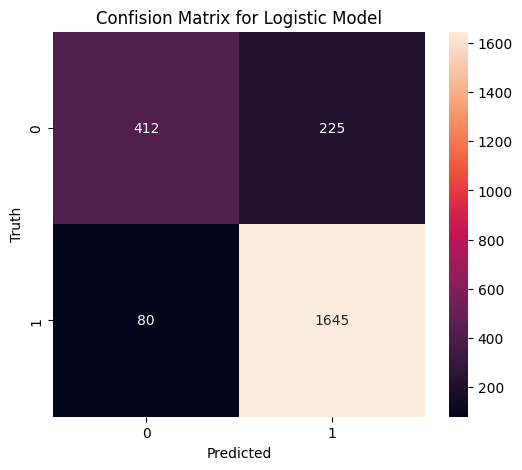

In [130]:

cm=confusion_matrix(y_test,y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.title("Confision Matrix for Logistic Model")
plt.show()

In [131]:
# navie bayes
from sklearn.naive_bayes import MultinomialNB
nb_model=Pipeline(
    [
        ('tfid',TfidfVectorizer(ngram_range=(1,2),max_features=50000)),
        ('clf',MultinomialNB())
    ]
)

In [132]:
nb_model.fit(X_train,y_train)

Pipeline(steps=[('tfid',
                 TfidfVectorizer(max_features=50000, ngram_range=(1, 2))),
                ('clf', MultinomialNB())])

In [133]:
y_predn=nb_model.predict(X_test)

In [ ]:
accuracy_score(y_test,y_predn)

0.8357324301439458

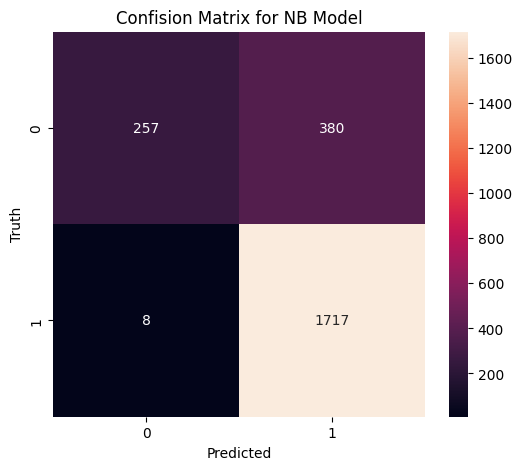

In [134]:
cm=confusion_matrix(y_test,y_predn)
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.title("Confision Matrix for NB Model")
plt.show()

# Save Model

In [135]:
# save the best model
import joblib
joblib.dump(logistic_model,'BanglasentimentModel.pkl')
print('Model Saved Successfully')

Model Saved Successfully


# Load saved Model

In [136]:
import joblib
joblib.dump(logistic_model,'BanglasentimentModel.pkl')
print('Model Saved Successfully')


Model Saved Successfully


In [137]:
model=joblib.load('/content/BanglasentimentModel.pkl')

In [138]:
model

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=50000, ngram_range=(1, 2))),
                ('clf', LogisticRegression(max_iter=1000))])

In [139]:

text="কাজল চোখের মেয়ে নাটকটি কার কার ভালো লেগেছে হাত তুল"
text=clean_text(text)
text=remove_stopwords(text)
prediction=model.predict([text])[0]
if prediction==1:
  print("Positive")
else:
  print("Negative")

Positive


In [140]:
model.predict([text])[0]

np.int64(1)

# Streamlit UI for Sentiment Analysis

Overwriting app.py


In [142]:
!pip install streamlit pyngrok -qq
from pyngrok import ngrok

# Terminate any previous ngrok tunnels
ngrok.kill()

# Start a new ngrok tunnel
public_url = ngrok.connect(8501)
print(f"Streamlit App URL: {public_url}")

# Run the Streamlit app in the background
!streamlit run app.py &>/dev/null&

ERROR:pyngrok.process.ngrok:t=2026-07-21T20:26:33+0000 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="authentication failed: The authtoken you specified does not look like a proper ngrok authtoken.\nYour authtoken: YOUR_AUTHTOKEN\nInstructions to install your authtoken are on your ngrok dashboard:\nhttps://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_105\r\n"
ERROR:pyngrok.process.ngrok:t=2026-07-21T20:26:33+0000 lvl=eror msg="session closing" obj=tunnels.session err="authentication failed: The authtoken you specified does not look like a proper ngrok authtoken.\nYour authtoken: YOUR_AUTHTOKEN\nInstructions to install your authtoken are on your ngrok dashboard:\nhttps://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_105\r\n"


PyngrokNgrokError: The ngrok process errored on start: authentication failed: The authtoken you specified does not look like a proper ngrok authtoken.\nYour authtoken: YOUR_AUTHTOKEN\nInstructions to install your authtoken are on your ngrok dashboard:\nhttps://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_105\r\n.